In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('imdb_top_1000.csv')
df.drop(['Poster_Link', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'Overview', 'Meta_score','Director', 'Star1', 'Star2' , 'Star3', 'Star4', 'No_of_Votes', 'Gross'], axis=1, inplace=True)
df.head()

,Series_Title,IMDB_Rating
0,The Shawshank Redemption,9.3
1,The Godfather,9.2
2,The Dark Knight,9.0
3,The Godfather: Part II,9.0
4,12 Angry Men,9.0


In [3]:
from plotly.offline import init_notebook_mode, plot, iplot
import plotly.graph_objs as go
init_notebook_mode(connected=True)

In [4]:
data = df['IMDB_Rating'].value_counts().sort_index(ascending=False)
trace = go.Bar(x = data.index,
               text = ['{:.1f} %'.format(val) for val in (data.values / df.shape[0] * 100)],
               textposition = 'auto',
               textfont = dict(color = '#000000'),
               y = data.values,
               )

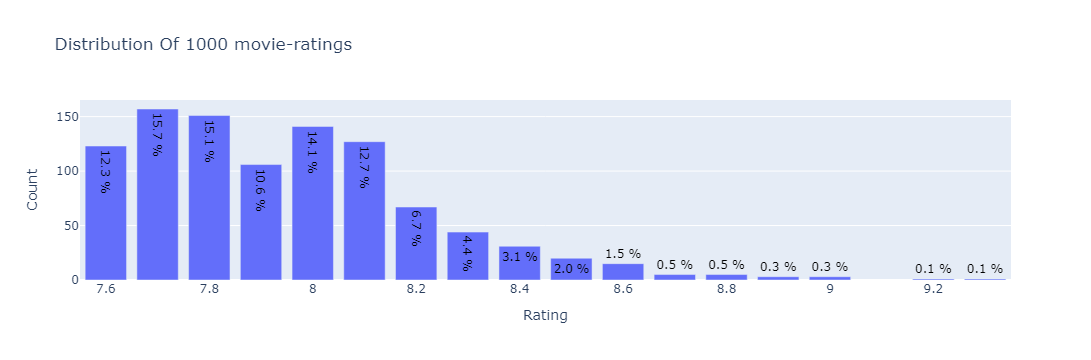

In [5]:
# Create layout
layout = dict(title = 'Distribution Of {} movie-ratings'.format(df.shape[0]),
              xaxis = dict(title = 'Rating'),
              yaxis = dict(title = 'Count'))
# Create plot
fig = go.Figure(data=[trace], layout=layout)
iplot(fig)

In [6]:
# Number of ratings per movie
data = df.groupby('Series_Title')['IMDB_Rating'].count().clip(upper=500)

In [7]:
# Create trace
trace = go.Histogram(x = data.values,
                     name = 'Ratings',
                     xbins = dict(start = 0,
                                  end = 500,
                                  size = 2))

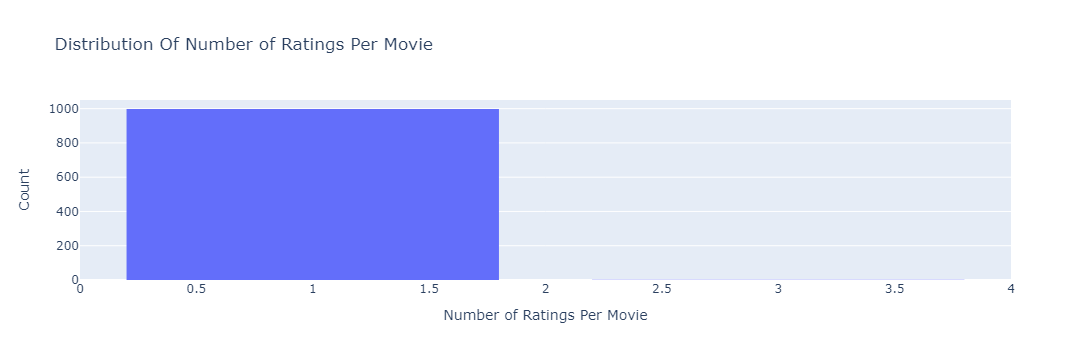

In [8]:
# Create layout
layout = go.Layout(title = 'Distribution Of Number of Ratings Per Movie',
                   xaxis = dict(title = 'Number of Ratings Per Movie'),
                   yaxis = dict(title = 'Count'),
                   bargap = 0.2)

# Create plot
fig = go.Figure(data=[trace], layout=layout)
iplot(fig)

In [9]:
print('Data frame shape:\t{}'.format(df.shape))

Data frame shape:	(1000, 2)
